# About

- Load `tfrecord` and build `tf.data` dataloader.
    - **Note**: This can be replaced with `torch.utils.data.DataLoader`. 
- Use `medicai` for volume transformation and **3D** model, i.e. [`SegFormer3D`](https://arxiv.org/abs/2404.10156) - written in **Keras 3**.
    - Will use `torch` backend.
- Train the model with pure **PyTorch** custom training pipeline. [Learn](https://keras.io/guides/writing_a_custom_training_loop_in_torch/) more about it.

In [1]:
from IPython.display import clear_output

var="/kaggle/input/vsdetection-packages-offline-installer-only/whls"
!pip install \
    "$var"/keras_nightly-3.12.0.dev2025100703-py3-none-any.whl \
    --no-index \
    --find-links "$var"

!pip install git+https://github.com/innat/medic-ai.git -q
clear_output()

In [2]:
import glob
from tqdm import tqdm
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import os, warnings
os.environ["KERAS_BACKEND"] = "torch"
warnings.filterwarnings('ignore')

In [3]:
import keras
from keras import ops
from keras.optimizers import SGD, AdamW, Muon
from keras.optimizers.schedules import CosineDecay, PolynomialDecay

import torch
import tensorflow as tf

# keras.mixed_precision.set_global_policy("mixed_float16")
keras.version(), torch.__version__, keras.config.backend()

2026-02-02 17:06:45.687761: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770052006.007278      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770052006.103539      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770052006.912074      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770052006.912124      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770052006.912127      24 computation_placer.cc:177] computation placer alr

('3.12.0.dev2025100703', '2.8.0+cu126', 'torch')

In [4]:
# mainly for 3D or 2D models, transformation, loss, metrics etc
import medicai
from medicai.transforms import (
    Compose,
    NormalizeIntensity,
    ScaleIntensityRange,
    Resize,
    RandShiftIntensity,
    RandRotate90,
    RandRotate,
    RandFlip,
    RandCutOut,
    RandSpatialCrop
)
from medicai.layers import ResizingND
from medicai.models import (
    UNet, SegFormer, TransUNet, SwinUNETR, UPerNet, ConvNeXtV2Tiny, UNETRPlusPlus
)
from medicai.losses import (
    SparseDiceCELoss, SparseTverskyLoss, SparseCenterlineDiceLoss
)
from medicai.metrics import SparseDiceMetric
from medicai.callbacks import SlidingWindowInferenceCallback
from medicai.utils import SlidingWindowInference
from medicai.utils import soft_skeletonize

## Data Loader

In [5]:
input_shape=(128, 128, 128)
batch_size=1
num_classes=3

# Each tfrecord contains 6 samples, total 786 samples.
num_samples = 780
epochs = 50

In [6]:
def train_transformation(image, label):
    data = {"image": image, "label": label}
    pipeline = Compose([
        ## Geometric transformation
        RandSpatialCrop(
            keys=["image", "label"],
            roi_size=input_shape,
            random_center=True,
            random_size=False,
            invalid_label=2,         
            min_valid_ratio=0.5,     
            max_attempts=10
        ),
        RandFlip(keys=["image", "label"], spatial_axis=[0], prob=0.5),
        RandFlip(keys=["image", "label"], spatial_axis=[1], prob=0.5),
        RandFlip(keys=["image", "label"], spatial_axis=[2], prob=0.5),
        RandRotate90(
            keys=["image", "label"], 
            prob=0.4, 
            max_k=3, 
            spatial_axes=(0, 1)
        ),

        ## Z-score norm
        NormalizeIntensity(
            keys=["image"], 
            nonzero=True,
            channel_wise=False
        ),

        ## Intensiry transformation
        RandShiftIntensity(
            keys=["image"], offsets=0.10, prob=0.5
        ),
        
        ## Spatial transformation 
        RandCutOut(
            keys=["image", "label"],
            invalid_label=2, 
            mask_size=[
                input_shape[1]//4,
                input_shape[2]//4
            ],
            fill_mode="constant", # "constant", "gaussian"
            cutout_mode='volume', # "slice", "volume"
            prob=0.2,
            num_cuts=2,
        ),
    ])
    result = pipeline(data)
    return result["image"], result["label"]


def val_transformation(image, label):
    data = {"image": image, "label": label}
    pipeline = Compose([
        NormalizeIntensity(
            keys=["image"], 
            nonzero=True,
            channel_wise=False
        ),
    ])
    result = pipeline(data)
    return result["image"], result["label"]

In [7]:
def parse_tfrecord_fn(example):
    feature_description = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.string),
        "image_shape": tf.io.FixedLenFeature([3], tf.int64),
        "label_shape": tf.io.FixedLenFeature([3], tf.int64),
    }
    parsed_example = tf.io.parse_single_example(example, feature_description)
    image = tf.io.decode_raw(parsed_example["image"], tf.uint8)
    label = tf.io.decode_raw(parsed_example["label"], tf.uint8)
    image_shape = tf.cast(parsed_example["image_shape"], tf.int64)
    label_shape = tf.cast(parsed_example["label_shape"], tf.int64)
    image = tf.reshape(image, image_shape)
    label = tf.reshape(label, label_shape)
    return image, label

In [8]:
def prepare_inputs(image, label):
    # Add channel dimension
    image = image[..., None] # (D, H, W, 1)
    label = label[..., None] # (D, H, W, 1)

    # Convert to float32
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label

In [9]:
def tfrecord_loader(tfrecord_pattern, batch_size=1, shuffle=True):
    dataset = tf.data.TFRecordDataset(
        tf.io.gfile.glob(tfrecord_pattern)
    )
    dataset = dataset.shuffle(buffer_size=100) if shuffle else dataset 
    dataset = dataset.map(
        parse_tfrecord_fn, num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.map(
        prepare_inputs,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if shuffle:
        dataset = dataset.map(
            train_transformation,
            num_parallel_calls=tf.data.AUTOTUNE
        )
    else:
        dataset = dataset.map(
            val_transformation,
            num_parallel_calls=tf.data.AUTOTUNE
        )
    dataset = dataset.batch(batch_size, drop_remainder=shuffle)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

In [10]:
all_tfrec = sorted(
    glob.glob("/kaggle/input/vesuvius-tfrecords/*.tfrec"),
    key=lambda x: int(x.split("_")[-1].replace(".tfrec", ""))
)

val_idx = -1
val_patterns = [all_tfrec[val_idx]]
train_patterns = [
    f for i, f in enumerate(all_tfrec) if i != len(all_tfrec) + val_idx
]

train_ds = tfrecord_loader(
    train_patterns, batch_size=batch_size, shuffle=True
)
val_ds = tfrecord_loader(
    val_patterns, batch_size=1, shuffle=False
)

I0000 00:00:1770052019.390819      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [11]:
x, y = next(iter(val_ds))
x.shape, y.shape 

(TensorShape([1, 320, 320, 320, 1]), TensorShape([1, 320, 320, 320, 1]))

In [12]:
def plot_sample(x, y, sample_idx=0, max_slices=16):
    img = np.squeeze(x[sample_idx])  # (D, H, W)
    mask = np.squeeze(y[sample_idx])  # (D, H, W)
    D = img.shape[0]

    # Decide which slices to plot
    step = max(1, D // max_slices)
    slices = range(0, D, step)

    n_slices = len(slices)
    fig, axes = plt.subplots(2, n_slices, figsize=(3*n_slices, 6))

    for i, s in enumerate(slices):
        axes[0, i].imshow(img[s], cmap='gray')
        axes[0, i].set_title(f"Slice {s}")
        axes[0, i].axis('off')

        axes[1, i].imshow(mask[s], cmap='gray')
        axes[1, i].set_title(f"Mask {s}")
        axes[1, i].axis('off')

    plt.suptitle(f"Sample {sample_idx}")
    plt.tight_layout()
    plt.show()

In [13]:
def plot_planes(image, mask, alpha=0.4):
    # Central slices
    d, h, w = image.shape
    axial_img    = image[d // 2]
    coronal_img  = image[:, h // 2, :]
    sagittal_img = image[:, :, w // 2]

    axial_msk    = mask[d // 2]
    coronal_msk  = mask[:, h // 2, :]
    sagittal_msk = mask[:, :, w // 2]

    slices_img = [axial_img, coronal_img, sagittal_img]
    slices_msk = [axial_msk, coronal_msk, sagittal_msk]
    
    titles = ["Axial (XY plane)", "Coronal (XZ plane)", "Sagittal (YZ plane)"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, ax in enumerate(axes):
        ax.imshow(slices_img[i], cmap="gray")

        # overlay jet only where mask > 0
        m = slices_msk[i]
        if m.max() > 0:
            ax.imshow(m, cmap="jet", alpha=alpha)

        ax.set_title(titles[i])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

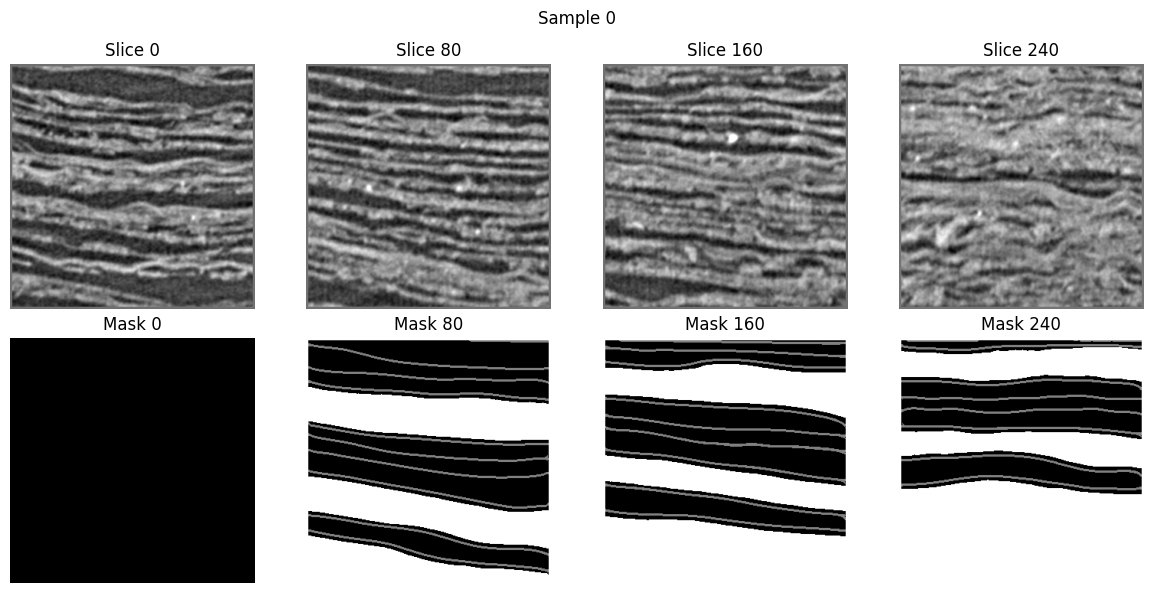

In [14]:
plot_sample(
    x, y, sample_idx=0, max_slices=4
)

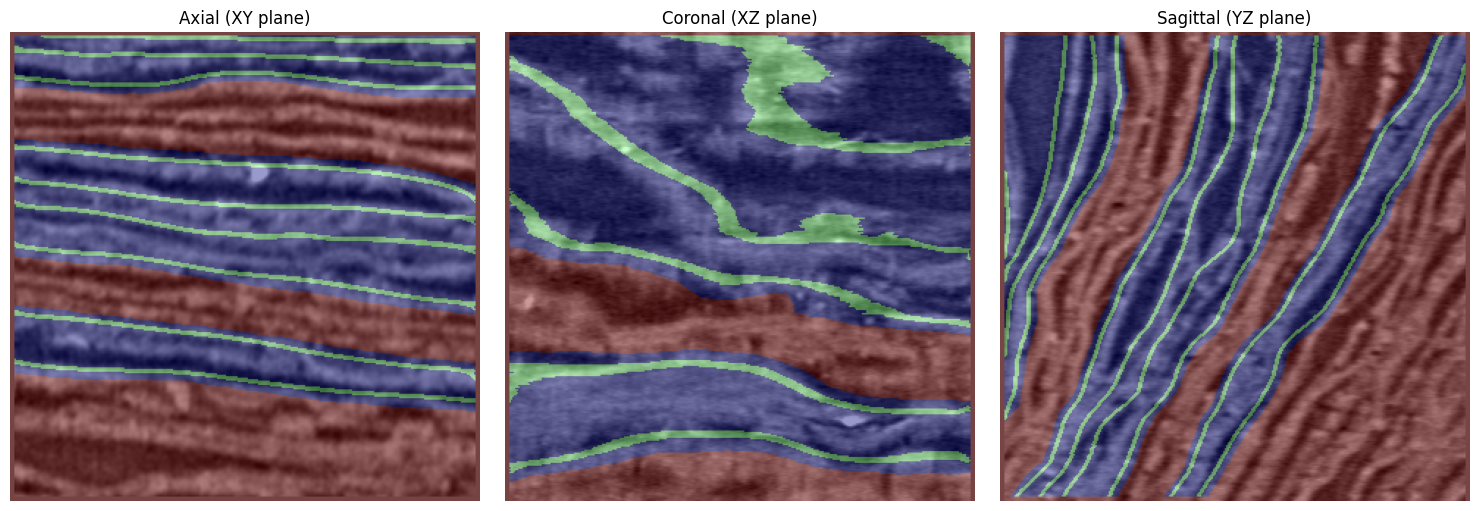

In [15]:
plot_planes(
    np.squeeze(x[0]), # picking one sample
    np.squeeze(y[0])  # picking one sample
)

## Model

In [16]:
# medicai.models.list_models()

In [17]:
model = SegFormer(
    input_shape=input_shape + (1,),
    encoder_name='mit_b0',
    classifier_activation='softmax',
    num_classes=num_classes,
    dropout=0.2,
)
model.count_params() / 1e6

4.501027

In [18]:
# ALERT: This attributes only available in medicai (not in core keras)
try:
    print(model.instance_describe())
except AttributeError:
    pass

Instance of SegFormer
  • input_shape: (128, 128, 128, 1)
  • encoder: MixViTB0(
    • input_shape: (128, 128, 128, 1)
    • include_rescaling: False
    )
  • encoder_name: 'mit_b0'
  • num_classes: 3
  • classifier_activation: softmax
  • decoder_head_embedding_dim: 256
  • dropout: 0.2


## Training Pipeline

In [19]:
steps_per_epoch = num_samples // batch_size
total_steps = steps_per_epoch * epochs
warmup_steps = int(total_steps * 0.05)
decay_steps = max(1, total_steps - warmup_steps)
lr_schedule = CosineDecay(
    initial_learning_rate=1e-6,
    decay_steps=decay_steps,
    warmup_target=min(3e-4, 1e-4 * (batch_size / 2)),
    warmup_steps=warmup_steps,
    alpha=0.1,
)

In [20]:
# define optomizer, loss, metrics
optim = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-5,
)

dice_ce_loss_fn = SparseDiceCELoss(
    from_logits=False, 
    num_classes=num_classes,
    ignore_class_ids=2,
)
cldice_loss_fn = SparseCenterlineDiceLoss(
    from_logits=False, 
    num_classes=num_classes,
    target_class_ids=1,
    ignore_class_ids=2,
    iters=1, # ideal to set 20-50 - computationally expensive
)
combined_loss_fn = lambda y_true, y_pred: (
    dice_ce_loss_fn(y_true, y_pred) + cldice_loss_fn(y_true, y_pred)
)

In [21]:
# define sliding-window-inferencer for validation
swi = SlidingWindowInference(
    model,
    num_classes=num_classes,
    roi_size=input_shape,
    sw_batch_size=1,
    overlap=0.5,
    mode='gaussian',
)

In [22]:
def train_one_epoch(model, dataloader, metrics):
    loop = tqdm(dataloader, desc="Training", leave=False)
    
    for imgs, labels in loop:
        # forward pass
        outputs = model(imgs)
        loss = combined_loss_fn(labels, outputs)

        # backward pass
        model.zero_grad()
        trainable_weights = [v for v in model.trainable_weights]

        # call torch.Tensor.backward() on the loss to compute gradients
        loss.backward()
        gradients = [v.value.grad for v in trainable_weights]

        # update weights
        with torch.no_grad():
            optim.apply(gradients, trainable_weights)

        # update training metric
        metrics.update_state(
            ops.convert_to_tensor(labels), 
            ops.convert_to_tensor(outputs)
        )
        
        # Update tqdm
        loss_score = ops.convert_to_numpy(loss)
        metrics_score = ops.convert_to_numpy(metrics.result())
        loop.set_postfix(
            loss=loss_score,
            dice=metrics_score,
        )

    return loss, metrics

In [23]:
def validate(model, dataloader, metrics):
    for sample in dataloader:
        x, y = sample
        output = swi(x)
        y = ops.convert_to_tensor(y)
        output = ops.convert_to_tensor(output)
        metrics.update_state(y, output)
    return metrics

In [24]:
def run_training(train_loader, val_loader, model, epochs=20):
    # metrics for train
    train_metrics = SparseDiceMetric(
        from_logits=False, 
        num_classes=num_classes, 
        ignore_class_ids=2,
        name='dice'
    )

    # metrics for validation
    val_metrics = SparseDiceMetric(
        from_logits=False, 
        num_classes=num_classes, 
        ignore_class_ids=2,
        name='val_dice'
    )
    
    # Initialize best validation dice score
    best_val_dice = 0.0

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        
        # Training
        loss, train_metrics = train_one_epoch(
            model, train_loader, train_metrics,
        )
        # display training logs at the end of epoch
        train_metrics_score = ops.convert_to_numpy(train_metrics.result())
        loss_score = ops.convert_to_numpy(loss)
        
        # reset training metrics at the end of each epoch
        train_metrics.reset_state()

        # Validation [at every 5 epoch]
        if (epoch + 1) % 2 == 0:
            val_metrics = validate(model, val_loader, val_metrics)
            val_metrics_score = ops.convert_to_numpy(
                val_metrics.result()
            )
            val_metrics.reset_state()
            print(
                f'Training - Loss: {loss_score:.4f}, Dice: {train_metrics_score:.4f}'
                f'\nValidation - Dice: {val_metrics_score:.4f}\n'
            )

            # Save best model weights
            if val_metrics_score > best_val_dice:
                best_val_dice = val_metrics_score
                model.save_weights('model.weights.h5')
                # torch.save(model.state_dict(), 'model.pth') # OK too.
                print(
                    f'Dice score improved: {best_val_dice}. Model saved.'
                )
        else:
            print(
                f'Training - Loss: {loss_score:.4f}, Dice: {train_metrics_score:.4f}\n'
            )

In [25]:
run_training(
    train_ds, val_ds, model, epochs=epochs
)

Epoch 1/50


Training - Loss: 1.6385, Dice: 0.6710

Epoch 2/50


Total patch 64: 100%|██████████| 64/64 [00:18<00:00,  3.55it/s]


Training - Loss: 1.4523, Dice: 0.6892
Validation - Dice: 0.5378

Dice score improved: 0.5378133058547974. Model saved.
Epoch 3/50


Training - Loss: 1.6415, Dice: 0.6903

Epoch 4/50


...

Total patch 64: 100%|██████████| 64/64 [00:18<00:00,  3.48it/s]


Training - Loss: 1.4930, Dice: 0.7229
Validation - Dice: 0.5659

Dice score improved: 0.5658835768699646. Model saved.
Epoch 49/50


Training - Loss: 1.3057, Dice: 0.7213

Epoch 50/50


Total patch 64: 100%|██████████| 64/64 [00:18<00:00,  3.54it/s]


Training - Loss: 1.3067, Dice: 0.7229
Validation - Dice: 0.5680

Dice score improved: 0.5679911375045776. Model saved.


In [26]:
x, y = next(iter(val_ds))
x.shape, y.shape

(TensorShape([1, 320, 320, 320, 1]), TensorShape([1, 320, 320, 320, 1]))

In [27]:
y_pred = swi(x)
y_pred.shape

Total patch 64: 100%|██████████| 64/64 [00:18<00:00,  3.47it/s]


(1, 320, 320, 320, 3)

In [28]:
segment = y_pred.argmax(-1).astype(np.uint8)
segment.shape, np.unique(segment)

((1, 320, 320, 320), array([0, 1], dtype=uint8))

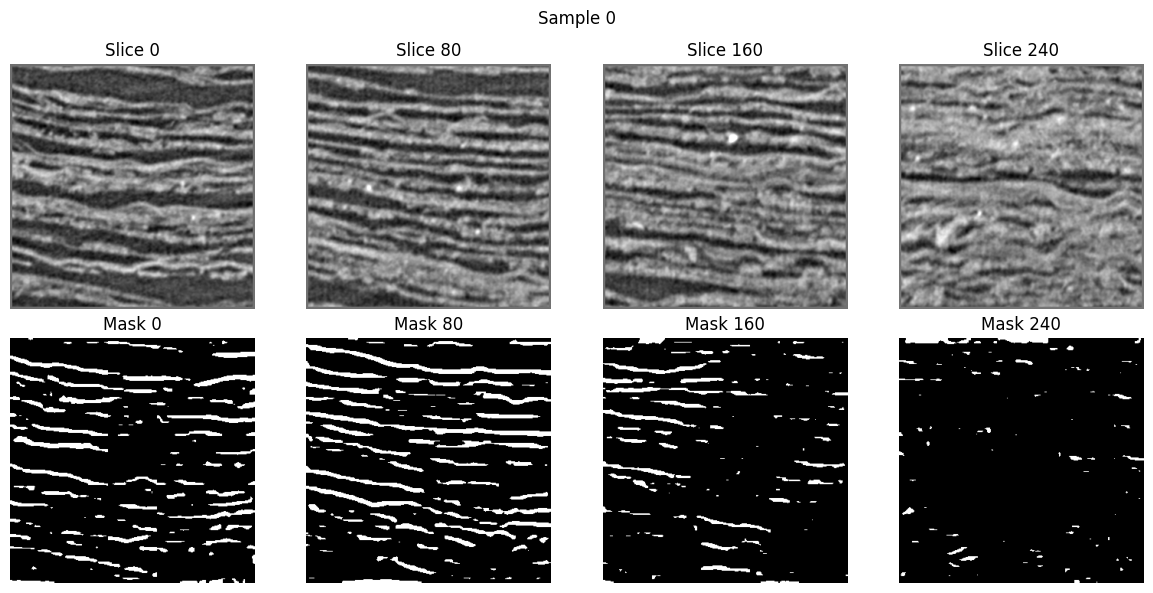

In [29]:
plot_sample(
    x, segment, sample_idx=0, max_slices=4
)